In [1]:
import sys
from pathlib import Path
root = Path.cwd().parent
sys.path.append(str(root))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from core.normalizer import compute_wallmid3

In [3]:
HP = "HYDROGEL_PACK"
VELVE = "VELVETFRUIT_EXTRACT"
VE40 = "VEV_4000"
VE45 = "VEV_4500"
VE50 = "VEV_5000"
VE51 = "VEV_5100"
VE52 = "VEV_5200"
VE53 = "VEV_5300"
VE54 = "VEV_5400"
VE55 = "VEV_5500"
VE60 = "VEV_6000"
VE65 = "VEV_6500"

products = {
    "HP": HP, "VELVE": VELVE,
    "VE40": VE40, "VE45": VE45, "VE50": VE50, "VE51": VE51,
    "VE52": VE52, "VE53": VE53, "VE54": VE54, "VE55": VE55,
    "VE60": VE60, "VE65": VE65
}

path = "/Users/alexoddsh/prosperity/backend/backtester/resources-4/round3/"

price_files = ["prices_round_3_day_0.csv", "prices_round_3_day_1.csv", "prices_round_3_day_2.csv"]
trade_files = ["trades_round_3_day_0.csv", "trades_round_3_day_1.csv", "trades_round_3_day_2.csv"]

df_list = [pd.read_csv(path + f, sep=";") for f in price_files]
tf_list = [pd.read_csv(path + f, sep=";") for f in trade_files]

all_dfs = {}
all_tfs = {}

for key, symbol in products.items():
    p_days = []
    for i, df in enumerate(df_list):
        sub = df[df["product"] == symbol].copy()
        if i > 0:
            sub["timestamp"] += i * 1000000
        sub["mid_price"] = sub["mid_price"].ffill()
        p_days.append(sub)
    
    combined_df = pd.concat(p_days)
    fill_cols = ["ask_price_1", "bid_price_1", "ask_price_2", "bid_price_2", "ask_price_3", "bid_price_3"]
    existing = [c for c in fill_cols if c in combined_df.columns]
    combined_df[existing] = combined_df[existing].ffill()
    all_dfs[key] = combined_df

    t_days = []
    for i, tf in enumerate(tf_list):
        sub_t = tf[tf["symbol"] == symbol].copy()
        if i > 0:
            sub_t["timestamp"] += i * 1000000
        t_days.append(sub_t)
    all_tfs[key] = pd.concat(t_days)

globals().update({f"df_{k.lower()}": v for k, v in all_dfs.items()})
globals().update({f"tf_{k.lower()}": v for k, v in all_tfs.items()})

### Options ###

Gives the right but not obligation to buy or sell at the specified strike. American options can be exercised at anytime before expiry whilst European only a the date. To be clear there are 2 different "methods" to derive and calculate the BSM, both end up in similar places but one is less abstract (the PDE method) and one is more elegant (Martingale method). Here we do the PDE method.

**Options Pricing**
Black-Scholes on a European call option:
$$C = S\cdot N(d_1) - K \cdot e^{-rT} \cdot N(d_2)$$

Where:
- $S$ = Stock price
- $K$ = Exercise price
- $r$ = Risk-free rate
- $T$ = Time to expiry

Now whats the intuition behind this formula? It isn't really about expectations, its about replication. The idea behind the formula is from the sellers perspective. To sell an option they want to be delta-neutral. Their payoff is:

$$-max(S_T - K, 0) + C_t$$ 

So if the price rips and the bond ends ITM the loss of the seller is the price - strike (they need to buy it at S and sell to you at K). Thus to construct the option price (premium) we need to look at what is the cost of the seller to hedge in order to be delta neutral. 

**The Hedge**
The PDE method is often called the "delta-hedging" approach and it is grounded in the idea below. 

The seller can hedge by simply replicating the buyers payoff. If $S_T > K$ then the seller needs a portfolio with N amounts of stock that they can sell to the buyer. So the sellers portfolio needs to initially include the given amount of stock that the contract regards. But with a caveat, this only occurs if the call is ITM at expiry, so what they actually need is the stock amount X probability that the assets price path ends up ITM. 

To replicate the seller also needs to borrow in order to fund the purchase of stock. They do so via selling an amount of bonds. Specifically, we assume that these are default-free, zero-coupon bonds that pays $1 at time T (expiry date) and is worth $e{-rT}$ today. What amount of bonds? If the call ends ITM then the seller receives the strike price. This is a positive payoff, to be delta neutral they thus fund some of the stock purchase with debt, to be precise exactly the amount of debt that at the expiry date equals the strike price they receive, this explains the logic behind $Ke{-rT}$.

Now to maintain their delta-neutral position during the life of the call, they need to actively rebalance the amount of stock and bonds their hedging portfolio holds, think of these as $N(d_1)$ and $N(d_2)$. Via the portfolio of stocks and bonds the seller is deltra neutral but they accumulate a cost of maintaining this constant rebalancing. This is what the cost/premium of the option is. It is essentially the buyer, reimbursing the seller for the cost of hedging.

**BSM Intuition**
The magic that BLM introduces then is that it determines $N(d_1)$ and $N(d_2)$:
- $N(d_1)$ = Amount of stocks to hold now. If this is equal to 0.6 then we hold 60 stock per 100 stock contract.
- $N(d_2)$ = The risk adjusted probability. The prob. that the option will expire ITM (in a risk neutral world).

What is the cost of maintaining the quantity of stock? For example, if the price of the stock decreases the probability that it will expire ITM decreases, thus $N(d_1)$ so the seller sells some stock. Later price moves up, now $N(d_1)$ increases and the seller needs to buy stock at a higher price than what they sold for. These small price differences accumulate over time. It is due to the deeper market mechanic, any rebalancing that happens can only happen retrospectively, even if the seller is ultra quick in their actions they can only rebalance once the price has actually gone down and vice versa. 

Now the framing of C is multi-sided. It represents a) the initial equity that the seller needs to put up which is very clear in the BSM formula:

$$C = S\cdot N(d_1) - K \cdot e^{-rT} \cdot N(d_2)$$ 
(essentially: Equity = Assets - Debt)

It also represents b) the total accumulated cost of the constant rebalancing. Option b) is arguable the more "complete" framing/idea. Regardless these are mechanically always the same. Why? In a world with "No Arbitrage," the Initial Cost must equal the Future Cost.

- If the "Cost of Rebalancing" were expected to be $10, but the "Initial Equity" (Premium) was only $8, no one would ever sell the option.

- If the "Initial Equity" was $12, sellers would make a guaranteed profit, so competition would drive the price down to $10.

**The Solution**
First, we need to recall some basics regarding Itô's Lemma and Brownian motion:

**Brownian Motion**
We already know what Brownian motion is. The only less trivial component to add to not forget is that the increments are normally distributed. Let's say we go from time t to time s. Between this time, the increment in the asset price is normally distributed with mean 0 and variance (s-t). 

$$S_s - S_t ~ N(0, s-t)$$

Also remeber the other stuff, aka Brownian motion is independent of prior movement etc. What we formulate with Brownian motion (via the Weiner process) is the probability distribution for different movements of the price (variable). 

**Itô's Lemma** 
Now what is the end goal of modelling the Weinr process in BSM? It is finging probabilities for the different paths of the asset, or in other terms, what is the increment between t and s (end time). We can describe this increment as $dS$ (as done above). Now in ordinary calculus we can apply the Taylor Approximation:

$$S(x) = S(a) + S'(x)(x-a) + \frac{S''(x)}{2!}(x-a)^2 ...$$

Now also note that since we are actually looking for the change in $dS(x)$ we can disregard $S(a)$ which just sets the starting value.

$$dS(x) = S'(x) \cdot dx + \frac{f''(a)}{2!} \cdot (dx)^2 ... $$

Now as we know in ordinary calculus we can usually discard the second term as $dx$ is already very small and thus $(dx)^2$ is essentially 0. BUT our S(x) function is a function of a variable that depends on Brownian motion. Itô showed that for such an expression, we cannot disregard the second term in the expansion. 

Reason. Call the increment $dX = X_s - X_t$ Since Brownian motion increments are normally distributed with a mean of 0: $E[dX] = 0$. Now recall the formula for variance:

$$Var(x) = E[X^2] - (E[X])^2$$ 

Since $E[dX]$ = 0: $Var(dX) = E[(dX)^2]$ and by definition the variance of Brownian motion is $\Delta t$ thus:

$$E[(dx)^2] = \Delta t$$ 

Thus the $(dx)^2$ term will not compared to the order of the first term $dx$ be 0. Instead $frac{(dx)^2}{dx} = 1$ Thus we cannot disregard the second term in the Taylor expansion. 

### PDE Method ###

**Step 1**
We create a portfolio of $\Pi$ consting of Long one option with value $V(S, t)$ and short a specific amount of the underlying stock $\Delta$. Our goal is to find the $\Delta$ that makes the portfolio delta neutral to the random wiggles of the stock.

**Step 2**
We want to see how this portfolio changes over a tiny slice of time $dt$. 

$$d\Pi = dV - \Delta dS$$

Now we can substitute in the dynamics of the stock and the option into this equation. 
- Stock: $dS_t = \mu S_t dt + \sigma S_t dW_t$
- Option: $dV$ = $$dV \approx \underbrace{\frac{\partial V}{\partial t}dt}_{\text{Change from time}} + \underbrace{\frac{\partial V}{\partial S}dS}_{\text{Change from stock}} + \underbrace{\frac{1}{2}\frac{\partial^2 V}{\partial t^2}(dt)^2 + \frac{\partial^2 V}{\partial S \partial t}(dt)(dS) + \frac{1}{2}\frac{\partial^2 V}{\partial S^2}(dS)^2}_{\text{Second-order terms}}$$

Now we need to apply Itô's Lemma to get rid of the terms that are too small to matter.
1. $(dt)^2$ -> to small (dt = 0) so term 1 dissapears
2. $(dt * dW) = (dt * \sqrt{dt}) = dt^{1.5}$ still too small, term 2 gone
3. $dW^2 = dt$ so this term stays

And thus the option dynamics become:
$$dV = \left( \frac{\partial V}{\partial t} + \mu S \frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} \right) dt + \sigma S \frac{\partial V}{\partial S} dW$$

**Step 3**
Plug both into our equation. We get:
$$d\Pi = \underbrace{\left[ \left( \frac{\partial V}{\partial t} + \mu S \frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} \right) dt + \sigma S \frac{\partial V}{\partial S} dW \right]}_{dV} - \Delta \underbrace{\left[ \mu S dt + \sigma S dW \right]}_{dS}$$

To make sense of this we group the terms based on are (dt) predictable or (dW) random. Our cleaned version becomes:
$$d\Pi = \underbrace{\left[ \frac{\partial V}{\partial t} + \mu S \frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} - \Delta \mu S \right] dt}_{\text{Deterministic part}} + \underbrace{\left( \sigma S \frac{\partial V}{\partial S} - \Delta \sigma S \right) dW}_{\text{Random part}}$$

Now the key element. Since we as the option seller ourselves select $\Delta$ Black and Scholes realised that we can choose it to make the entire random bracket 0 if: $\Delta = \frac{\partial V}{\partial S}$. Thus we are left with:
$$d\Pi = \underbrace{\left[ \frac{\partial V}{\partial t} + \mu S \frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} -  \frac{\partial V}{\partial S} \mu S \right] dt}_{\text{Deterministic part}}$$

And the $\mu$ terms cancel so:

$$d\Pi = \underbrace{\left[ \frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} \right] dt}_{\text{Deterministic part}}$$

**Step 4**
Since our portfolio is now riskless, it is basically a risk-free bank account it must grow at the risk free rate R:
$$d\Pi = r\Pi dt$$

So:
$$\left( \frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} \right) dt = r\Pi dt$$

We cancel dt. The substitute in our original: $\Pi = V - \Delta S$ which as we choose $\Delta$ is know $\Pi = V - \frac{\partial V}{\partial S}S$.

We get:
$$\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} = r\left( V - \frac{\partial V}{\partial S}S \right)$$

Which simplifies to:
$$\frac{\partial V}{\partial t} + rS\frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} - rV = 0$$

### The Greeks ###
These are derived from the above:
$$\underbrace{\Theta}_{\text{Theta}} + rS\underbrace{\Delta}_{\text{Delta}} + \frac{1}{2}\sigma^2 S^2 \underbrace{\Gamma}_{\text{Gamma}} = rV$$

- Theta ($\Theta$): How much value you lose per day just by waiting ($\frac{\partial V}{\partial t}$).
- Delta ($\Delta$): Your exposure to the stock price ($\frac{\partial V}{\partial S}$).
- Gamma ($\Gamma$): How fast your Delta changes ($\frac{\partial^2 V}{\partial S^2}$).

### More Greeks (and risks) ###
Each layer kills a different type of risk. The cleanest way to see it is to write your option's value as a function of two state variables — spot $S$ and vol $\sigma$ and Taylor-expand:


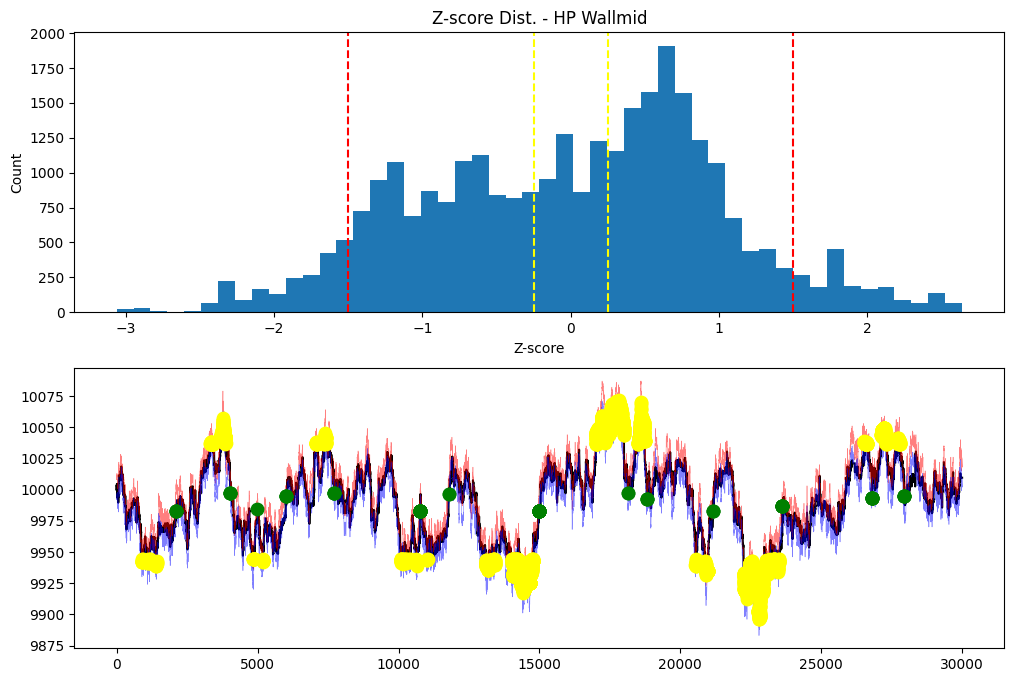

NULL HYPOTHESIS REJECTED: True
RHO: -0.0009715081734282309
PHI: 0.9990284918265717
REG EQUILIBRIUM: 9990.571806076006
T-STAT: -3.8086566358518077
P-VAL: 0.0028199777599586546
Half Life: 713.1287681248616
Mean Wallmid: 9990.246483333332
Std. Wallmid: 30.78900918189155
Z-Score Signals: 101


In [10]:
#Step 1/2 DF test
compute_wallmid3(HP, df_hp)
wallmid = df_hp["wallmid3"].ffill().bfill().to_numpy()
null_reject = False

#regression "c" -> variant 2 and "ct" = variant 3
#c for constant, t for trend
#Autolag=none means not augmented

result = adfuller(wallmid, maxlag=0, regression="c", autolag=None)
#adfuller returns t, p, rho hat

t_stat = result[0]
p_val = result[1]
critical_values = result[4]

if t_stat < critical_values["5%"]:
    null_reject = True

# Get Rho/Phi since adfuller doesnt extract it

#Note that this OLS will get RHO not PHI since we use delta y aka we have reparamaretized the original autoregression
#By subtracting y_{t-1} on both sides. Means the left side becomes delta Y and right side we use Rho = (Phi - 1) instead of
#Phi as the coefficient.

if null_reject:
    delta_y = np.diff(wallmid) #1st observation is dropped
    y_lag = wallmid[:-1] #1st observation is dropped
    X = add_constant(y_lag) #Just adds a column of ones so we have a 2D array where the 1s are used for the intercept alpha
    ols_res = OLS(delta_y, X).fit()
    intercept = ols_res.params[0]
    rho = ols_res.params[1]
    phi = rho + 1
    
    #Step 3 Check HL
    half_life = np.log(2) / -np.log(phi)

    #Step 4 check size and number of deviations and distribution
    mu_wallmid = wallmid.mean()
    sigma_wallmid = wallmid.std(ddof=1) #note delta degrees of freedom = 1 we want sample sigma!
    z_scores = (wallmid - mu_wallmid) / sigma_wallmid
    
    #check 
    above = np.abs(z_scores) > 1.5 #bool array
    crossings = np.diff(above.astype(int)) #convert bool array to 0,1s then do diff and we will have the crossings
    entry_crossings = np.where(crossings == 1)[0] +1 #because np diff drops one element

    entry_signals = np.sum(crossings == 1)
    entry_times = np.where(abs(z_scores) > 1.5)[0]

    exit_times = []
    for entry in entry_crossings:
        candidates = np.where(np.abs(z_scores[entry:]) < 0.25)[0]
        if len(candidates) > 0:
            exit_times.append(entry + candidates[0])

    exit_times = np.array(exit_times)

    fig, ax = plt.subplots(2 , 1, figsize=(12, 8))
    ax[0].hist(z_scores, bins=50)
    ax[0].set_title("Z-score Dist. - HP Wallmid")
    ax[0].axvline(x=1.5, color="red", linestyle="--")
    ax[0].axvline(x=-1.5, color="red", linestyle="--")
    ax[0].axvline(x=0.25, color="yellow", linestyle="--")
    ax[0].axvline(x=-0.25, color="yellow", linestyle="--")
    ax[0].set_xlabel("Z-score")
    ax[0].set_ylabel("Count")

    ax[1].plot(wallmid, color="black")
    ax[1].plot(df_hp["ask_price_1"].ffill().bfill().to_numpy(), color="red", linewidth=0.4, alpha=0.5)
    ax[1].plot(df_hp["bid_price_1"].ffill().bfill().to_numpy(), color="blue", linewidth=0.4, alpha=0.5)
    ax[1].scatter(entry_times, wallmid[entry_times], color="yellow", s=80, zorder=5, marker="o")
    ax[1].scatter(exit_times, wallmid[exit_times], color="green", s=80, zorder=5, marker="o")

    plt.show()
    

if not null_reject:
    print(f"NULL HYPOTHESIS REJECTED: {null_reject}")
elif null_reject:
    print(f"NULL HYPOTHESIS REJECTED: {null_reject}")
    print(f"RHO: {rho}")
    print(f"PHI: {phi}")
    print(f"REG EQUILIBRIUM: {-intercept/rho}")
    
    print(f"T-STAT: {t_stat}")
    print(f"P-VAL: {p_val}")
    
    print(f"Half Life: {half_life}")
    print(f"Mean Wallmid: {mu_wallmid}")
    print(f"Std. Wallmid: {sigma_wallmid}")
    print(f"Z-Score Signals: {entry_signals}")

